# Figure S2

Ruggedness inference on NK landscapes under biased mutation spectra. Repository products contain 250 estimates per $(N,K)$ pair.

## Setup

In [6]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import subprocess
import sys
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpec

from slide.utils import (
    FIGURE_LABEL_SIZE,
    FIGURE_LEGEND_SIZE,
    FIGURE_TICK_SIZE,
    FIGURE_TITLE_SIZE,
    PANEL_LETTER_SIZE,
    get_figures_dir,
    get_processed_data_dir,
    get_raw_data_dir,
    load_pickle,
    save_pickle,
)

OVERWRITE_RAW_PKL: bool = False
OVERWRITE_PROCESSED_PKL: bool = False
PLOT_ONLY: bool = True
SAVE_FIGURES: bool = True
PANEL_DPI: int = 350
SAVE_TYPES = ("pdf", "png", "eps")

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
REPO_ROOT = Path.cwd()
print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")
print(f"PLOT_ONLY={PLOT_ONLY}, OVERWRITE_RAW_PKL={OVERWRITE_RAW_PKL}, OVERWRITE_PROCESSED_PKL={OVERWRITE_PROCESSED_PKL}")


def save_figure(fig: Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save a figure in PDF, PNG, and EPS formats.

    Parameters:
    - fig: Figure
        Matplotlib figure to save.
    - stem: str
        Filename stem without an extension.
    - bbox_inches: str
        Bounding-box mode passed to Matplotlib.

    Returns:
    - None
        Files are written below ``FIGURES_DIR``.
    """
    for suffix in SAVE_TYPES:
        destination = FIGURES_DIR / suffix
        destination.mkdir(parents=True, exist_ok=True)
        fig.savefig(destination / f"{stem}.{suffix}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: Axes, letter: str) -> None:
    """Add a bold manuscript panel letter.

    Parameters:
    - ax: Axes
        Axis receiving the annotation.
    - letter: str
        Panel letter.

    Returns:
    - None
        The annotation is added directly to ``ax``.
    """
    ax.text(-0.14, 1.10, letter, transform=ax.transAxes, fontsize=PANEL_LETTER_SIZE,
            fontweight="bold", va="top", ha="left")

from slide.direvo_functions import get_single_decay_rate
from slide_config import get_slide_data_dir

SLIDE_DATA_DIR = Path(get_slide_data_dir())
PROCESSED_PATH = PROCESSED_DATA_DIR / "figureS2_biased_mutation_processed.pkl"
MODEL_FILES = {
    "E. coli": SLIDE_DATA_DIR / "large_decay_curve_sweep_codon_e_coli.pkl",
    "A. thaliana": SLIDE_DATA_DIR / "large_decay_curve_sweep_codon_a_thaliana.pkl",
    "Human": SLIDE_DATA_DIR / "large_decay_curve_sweep_codon_human.pkl",
}
N_VALUES: tuple[int, ...] = (10, 14, 18, 23, 27, 32, 36, 41, 45, 50)
NUM_ALLELES: int = 4
NUM_K_VALUES_PER_N: int = 10
NUM_LANDSCAPES_PER_PAIR: int = 25
NUM_POPULATION_REPLICATES: int = 10
POPULATION_SIZE: int = 2_500


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
raw_data: /home/idris/workspace_python/SLIDE/raw_data
processed_data: /home/idris/workspace_python/SLIDE/processed_data
figures: /home/idris/workspace_python/SLIDE/figures
PLOT_ONLY=True, OVERWRITE_RAW_PKL=False, OVERWRITE_PROCESSED_PKL=False


## Figure S2 Raw Products

In [7]:
if OVERWRITE_RAW_PKL and not PLOT_ONLY:
    subprocess.run([sys.executable, "scripts/large_decay_curve_sweep_codon.py"], cwd=REPO_ROOT, check=True)
missing_raw_paths = [path for path in MODEL_FILES.values() if not path.exists()]
print(f"Missing optional raw sweeps: {len(missing_raw_paths)}")


Missing optional raw sweeps: 3


## Figure S2 Processing

In [8]:
def load_figure_s2_payload() -> dict[str, object]:
    """Load and bin the cached Figure S2 biased-mutation estimates.

    Returns:
    - dict[str, object]
        Binned means and standard deviations for three mutation models.
    """
    processed = get_processed_data_dir()
    model_files = {
        "E. coli": "ruggedness_accuracy_codon_e_coli.pkl",
        "A. thaliana": "ruggedness_accuracy_codon_a_thaliana.pkl",
        "Human": "ruggedness_accuracy_codon_human.pkl",
    }
    data = {}
    for label, filename in model_files.items():
        true_rho, estimates = load_pickle(processed / filename)
        estimates = np.asarray(estimates, dtype=float)
        order = np.argsort(true_rho)
        grouped_true = np.asarray(true_rho, dtype=float)[order].reshape(10, -1)
        grouped_estimated = estimates.mean(axis=1)[order].reshape(10, -1)
        data[label] = {
            "true": grouped_true.mean(axis=1),
            "mean": grouped_estimated.mean(axis=1),
            "std": grouped_estimated.std(axis=1),
        }
    return {
        "data": data,
        "params": {
            "N_values": N_VALUES,
            "A": NUM_ALLELES,
            "K_values_per_N": NUM_K_VALUES_PER_N,
            "num_landscapes_per_pair": NUM_LANDSCAPES_PER_PAIR,
            "population_replicates": NUM_POPULATION_REPLICATES,
            "population_size": POPULATION_SIZE,
            "estimates_per_pair": 250,
            "M": 25,
            "mutation_rate": 0.5,
        },
        "metadata": {"paper_reference": "Figure S2", "caption_note": "Repository data contain 250, not 300, estimates."},
    }


def process_figure_s2_sweeps(raw_by_label: dict[str, np.ndarray]) -> dict[str, object]:
    """Fit and bin the three biased-mutation NK decay sweeps for Figure S2.

    Parameters:
    - raw_by_label: dict[str, np.ndarray]
        Raw sweep arrays keyed by display label.

    Returns:
    - dict[str, object]
        Binned means and standard deviations for plotting.
    """
    n_values = np.repeat(np.linspace(10, 50, 10), 10)
    k_values = np.concatenate([np.linspace(1, n_value, 10) for n_value in np.linspace(10, 50, 10)])
    true_rho = np.clip((k_values + 1) / n_values, 0, 1)[::-1]
    data = {}
    for label, raw in raw_by_label.items():
        curves = np.asarray(raw, dtype=float).reshape(100, -1, 25)
        curves /= np.maximum(curves[:, :, :1], 1e-10)
        estimates = np.zeros(curves.shape[:2], dtype=float)
        for pair_index in range(curves.shape[0]):
            for estimate_index in range(curves.shape[1]):
                estimates[pair_index, estimate_index] = get_single_decay_rate(
                    curves[pair_index, estimate_index], mut=0.5, num_steps=25
                )[0]
        order = np.argsort(true_rho)
        grouped_true = true_rho[order].reshape(10, -1)
        grouped_estimated = estimates.mean(axis=1)[order].reshape(10, -1)
        data[label] = {
            "true": grouped_true.mean(axis=1),
            "mean": grouped_estimated.mean(axis=1),
            "std": grouped_estimated.std(axis=1),
        }
    return {
        "data": data,
        "params": {
            "N_values": N_VALUES,
            "A": NUM_ALLELES,
            "K_values_per_N": NUM_K_VALUES_PER_N,
            "num_landscapes_per_pair": NUM_LANDSCAPES_PER_PAIR,
            "population_replicates": NUM_POPULATION_REPLICATES,
            "population_size": POPULATION_SIZE,
            "estimates_per_pair": 250,
            "M": 25,
            "mutation_rate": 0.5,
        },
        "metadata": {"paper_reference": "Figure S2", "caption_note": "Repository data contain 250 estimates."},
    }


if PROCESSED_PATH.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    figure_s2_payload = load_pickle(PROCESSED_PATH)
elif PLOT_ONLY:
    figure_s2_payload = load_figure_s2_payload()
else:
    if missing_raw_paths:
        listing = "\n".join(f"  - {path}" for path in missing_raw_paths)
        raise FileNotFoundError(f"Cannot rebuild Figure S2 processing; missing sweeps:\n{listing}")
    raw_by_label = {}
    for label, path in MODEL_FILES.items():
        with path.open("rb") as handle:
            raw_by_label[label] = np.asarray(pickle.load(handle))
    figure_s2_payload = process_figure_s2_sweeps(raw_by_label)
    save_pickle(figure_s2_payload, PROCESSED_PATH)

figure_s2_payload["params"].update({
    "N_values": N_VALUES,
    "A": NUM_ALLELES,
    "K_values_per_N": NUM_K_VALUES_PER_N,
    "num_landscapes_per_pair": NUM_LANDSCAPES_PER_PAIR,
    "population_replicates": NUM_POPULATION_REPLICATES,
    "population_size": POPULATION_SIZE,
    "estimates_per_pair": NUM_LANDSCAPES_PER_PAIR * NUM_POPULATION_REPLICATES,
    "M": 25,
    "mutation_rate": 0.5,
})
assert figure_s2_payload["params"]["estimates_per_pair"] == 250


## Individual Panels A–C

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


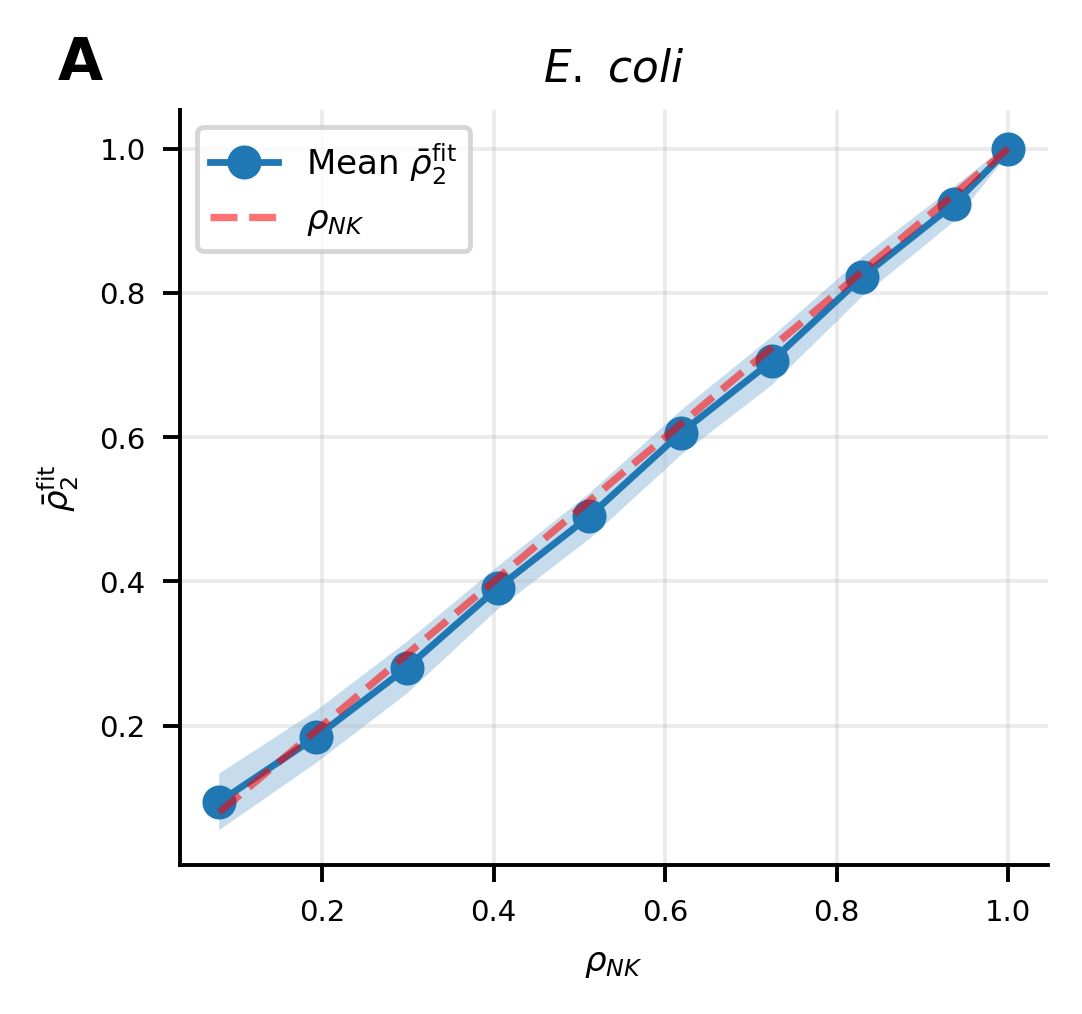

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


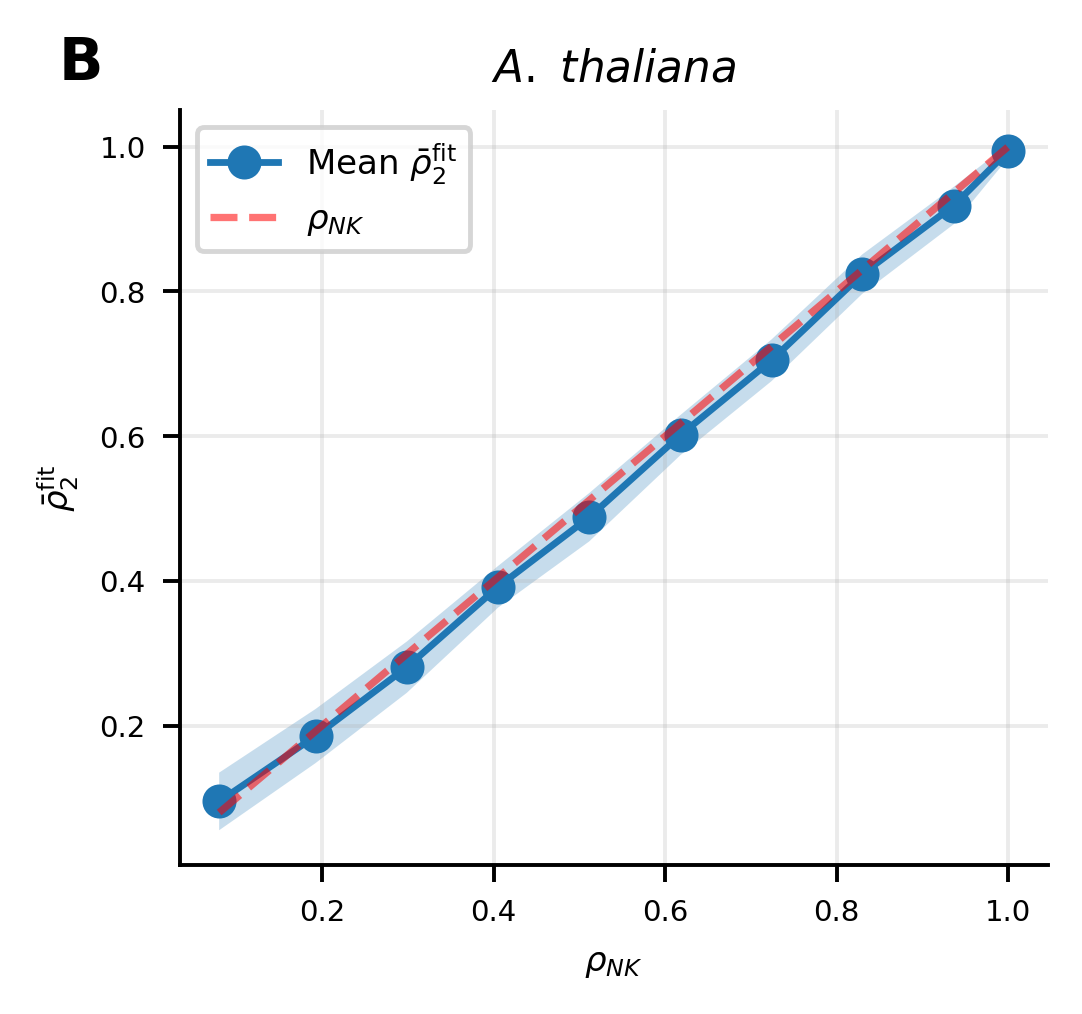

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


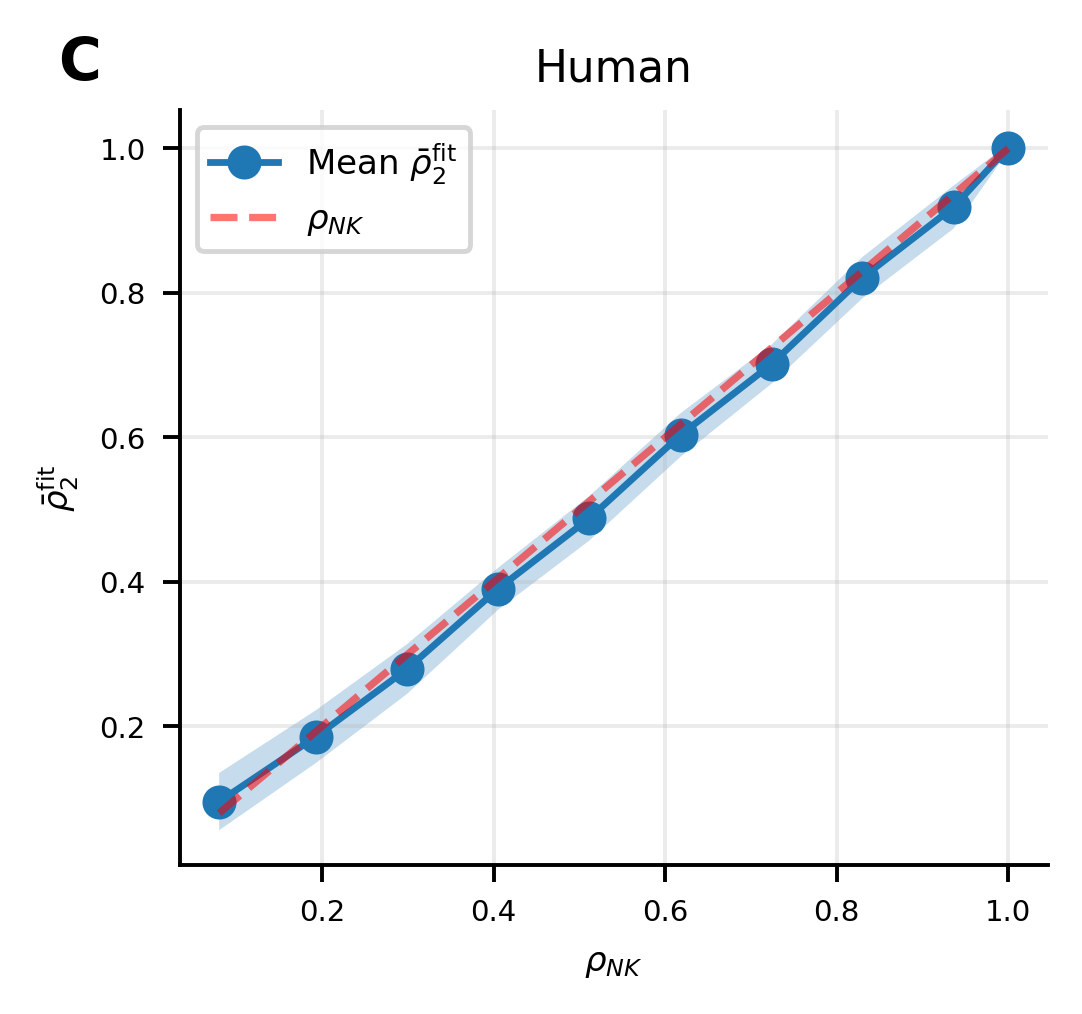

In [ ]:
def plot_s2_panel(ax: Axes, payload: dict[str, object], model_label: str) -> None:
    """Plot one biased-mutation ruggedness-accuracy panel.

    Parameters:
    - ax: Axes
        Axis receiving the plot.
    - payload: dict[str, object]
        Processed Figure S2 payload.
    - model_label: str
        Display label identifying the mutation model.

    Returns:
    - None
        Panel artists are added directly to ``ax``.
    """
    panel = payload["data"][model_label]  # type: ignore[index]
    if model_label == "E. coli":
        title = r"$\mathit{E.\ coli}$"
        rho = r"Mean $\rho_2^{\mathrm{fit}}$"
    elif model_label == "A. thaliana":
        title = r"$\mathit{A.\ thaliana}$"
        rho = r"Mean $\tilde{\rho}_2^{\mathrm{fit}}$"
    else:
        title = model_label
        rho = r"Mean $\bar{\rho}_2^{\mathrm{fit}}$"
    ax.plot(panel["true"], panel["mean"], "o-", linewidth=1.4, label=rho)
    ax.fill_between(panel["true"], panel["mean"] - panel["std"], panel["mean"] + panel["std"], alpha=0.25)
    ax.plot(panel["true"], panel["true"], color="red", linestyle="--", alpha=0.55, label=r"$\rho_{NK}$")
    ax.set_title(title, fontsize=FIGURE_TITLE_SIZE)
    ax.set_xlabel(r"$\rho_{NK}$", fontsize=FIGURE_LABEL_SIZE)
    ax.set_ylabel(r"$\rho_2$", fontsize=FIGURE_LABEL_SIZE)
    ax.tick_params(labelsize=FIGURE_TICK_SIZE)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, alpha=0.18)


for letter, label in zip("ABC", MODEL_FILES, strict=True):
    fig, ax = plt.subplots(figsize=(3.2, 2.8), dpi=PANEL_DPI)
    plot_s2_panel(ax, figure_s2_payload, label)
    ax.legend(frameon=True, fontsize=7)
    ax.grid(True, alpha=0.25)
    add_panel_letter(ax, letter)
    if SAVE_FIGURES:
        save_figure(fig, f"figure_S2{letter}")
    plt.show()


## Complete Figure S2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


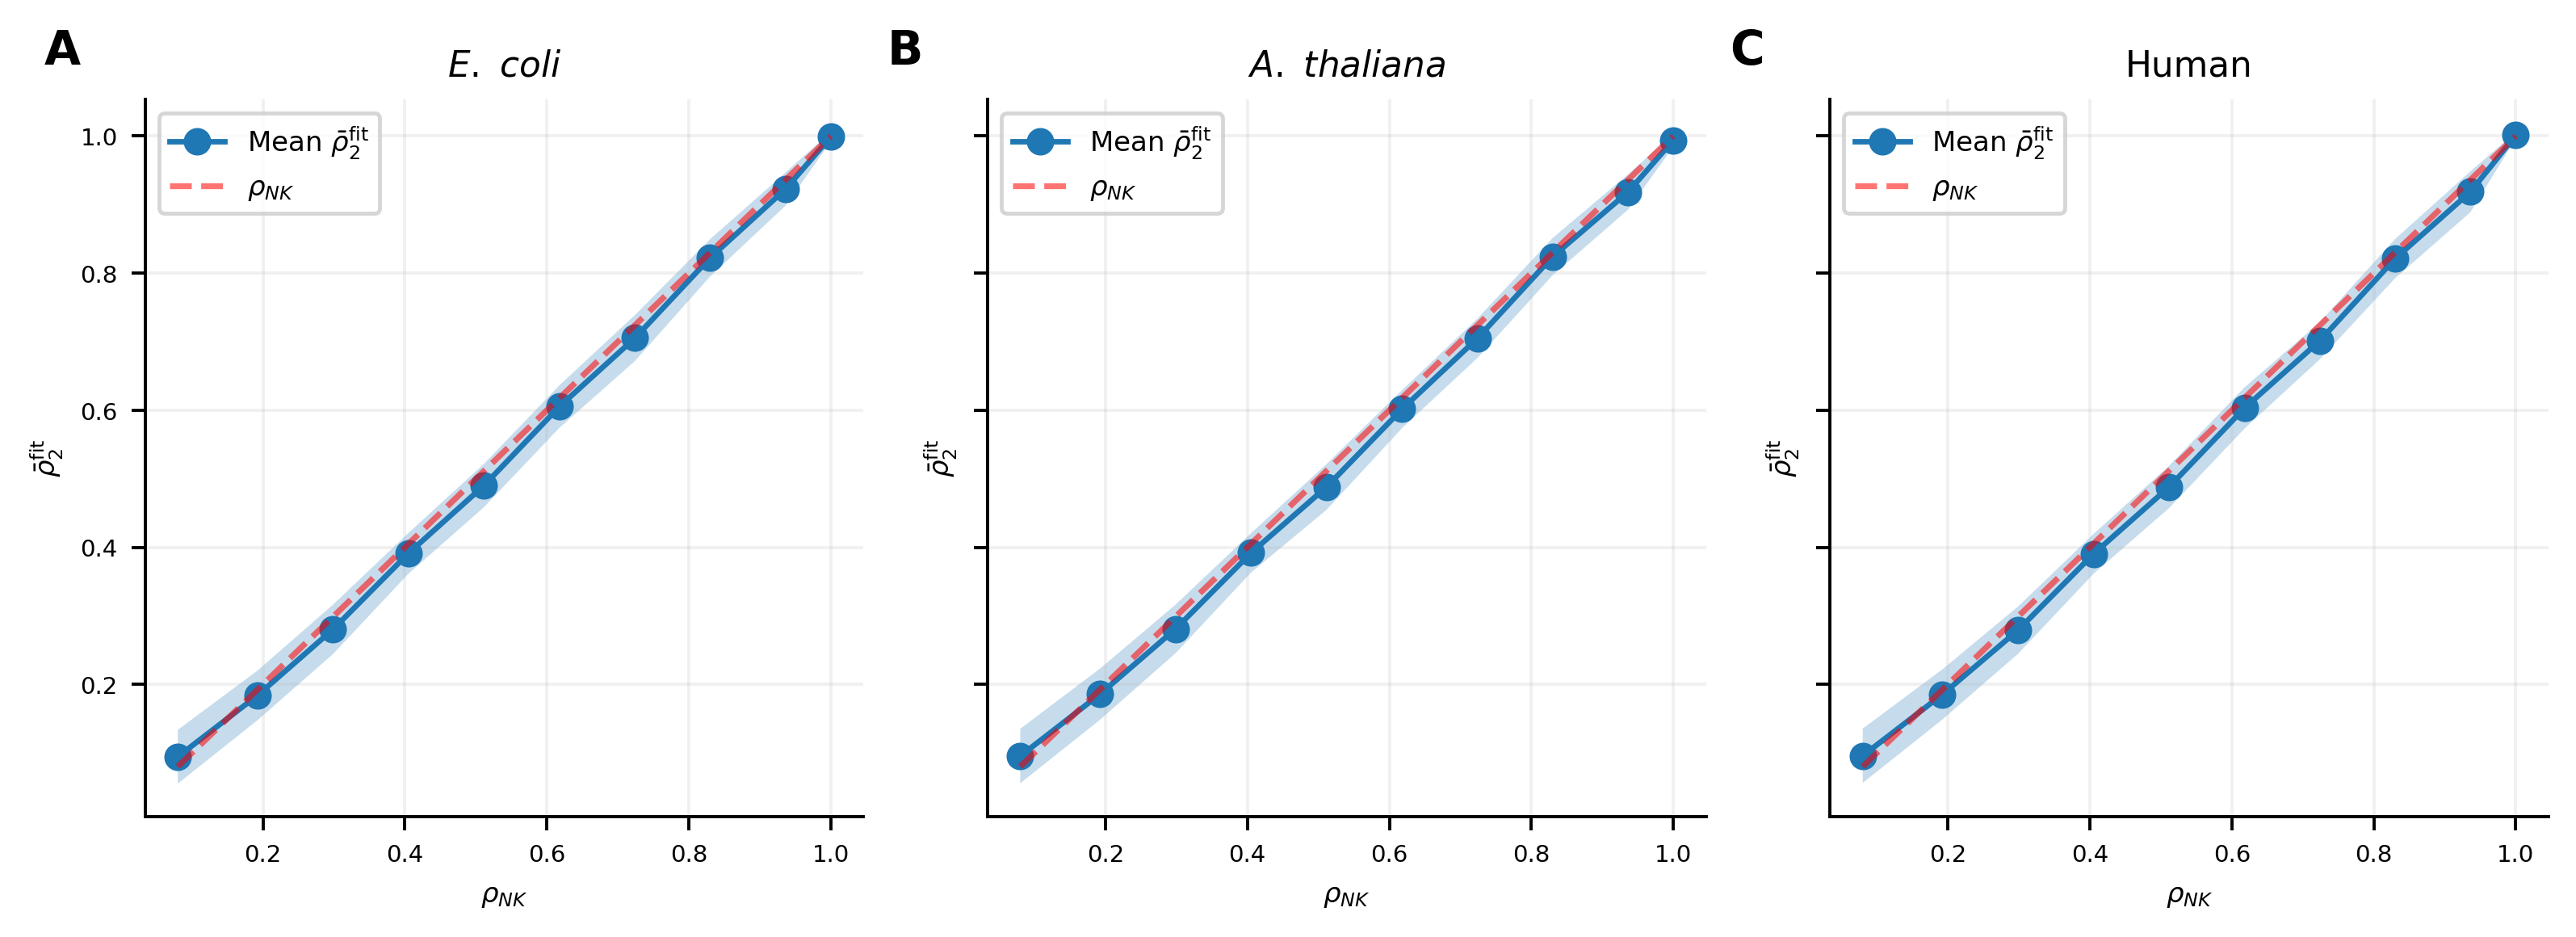

In [17]:
fig, axes = plt.subplots(
    1, 3, figsize=(9, 3.2), dpi=PANEL_DPI,
    constrained_layout=True, sharex=True, sharey=True,
)
for ax, letter, label in zip(axes, "ABC", MODEL_FILES, strict=True):
    plot_s2_panel(ax, figure_s2_payload, label)
    add_panel_letter(ax, letter)
    ax.legend(frameon=True, fontsize=7, loc="upper left")
if SAVE_FIGURES:
    save_figure(fig, "figure_S2")
plt.show()


## Manuscript Caption

```latex
\caption{\textbf{Replication of Fig.~\ref{fig:NK_ruggedness} using biased mutation spectra on $NK$ landscapes.} Ruggedness was evaluated on nucleotide-alphabet landscapes ($A=4$) using ten sequence lengths, $N \in \{10,14,18,23,27,32,36,41,45,50\}$, and ten $K$ values per $N$. Panels show results obtained with asymmetric, row-normalised $4\times4$ nucleotide transition kernels labelled for \textit{E. coli}, \textit{A. thaliana}, and human mutation spectra. For each $(N,K)$ pair, fitted squared-fitness decay rates were estimated from 250 decay curves (25 independently generated landscapes and 10 population replicates per landscape), using a population size of 2,500, 25 generations, and mutation rate $\theta=0.5$ per sequence per generation ($0.5/N$ per site). Points show means across the 250 estimates, shaded regions show one SD, and red dashed lines denote $\rho_{NK}=(K+1)/N$.}
```
